<a href="https://colab.research.google.com/github/siddhi-ms/Movie-Popularity-Driver/blob/main/movie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Analysis of Factors Influencing Movie Popularity in Bollywood

## 1. Introduction

Bollywood, India's thriving film industry, is a global cinematic powerhouse, producing hundreds of films annually for a vast and diverse audience. Understanding what drives a movie's success in such a competitive landscape is crucial for producers, directors, and investors.

In this project, we differentiate between two key metrics:

*   **Popularity**: Defined by the `votes` a movie receives, indicating audience engagement and reach.
*   **Ratings**: Representing the `quality` or critical reception of a movie.

This project focuses on **explainable analysis** to uncover the underlying factors that contribute to a movie's popularity within Bollywood. We aim to not just identify correlations, but to build models that can articulate *why* certain movies are perceived as more popular, providing actionable insights into the dynamics of the industry.

## 2. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

## 3. Load Dataset

In [2]:
df = pd.read_csv('movies.csv')
print("First 5 rows of the dataset:")
display(df.head())

print("\nShape of the dataset (rows, columns):")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

First 5 rows of the dataset:


,Film Name,Year,Duration,Ratings,Number of Rators,Summary,Votes
0,1. Animal,2023,3h 24m,7.3,(27K),A son's love for his father. Often away due to...,"26,740"
1,2. Tiger 3,2023,2h 34m,7.4,(42K),Tiger and Zoya are back - to save the country ...,"42,378"
2,3. Jawan,2023,2h 49mNot Rated,7.1,(78K),A high-octane action thriller which outlines t...,"78,258"
3,4. Starfish,2023,2h 1m,9.3,(15K),Beautiful journey through the depths of the un...,"15,422"
4,5. 12th Fail,2023,2h 27m,9.2,(9K),The real-life story of IPS Officer Manoj Kumar...,"9,031"



Shape of the dataset (rows, columns):
(4350, 7)

Column names:
['Film Name', 'Year', 'Duration', 'Ratings', 'Number of Rators', 'Summary', 'Votes']


## 4. Basic Data Understanding

In [3]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4350 entries, 0 to 4349
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Film Name         4350 non-null   object
 1   Year              4350 non-null   object
 2   Duration          3727 non-null   object
 3   Ratings           4350 non-null   object
 4   Number of Rators  3990 non-null   object
 5   Summary           4350 non-null   object
 6   Votes             4350 non-null   object
dtypes: object(7)
memory usage: 238.0+ KB


### Insights from `df.info()`:
*   The dataset contains `film_name`, `ratings`, `genre`, `director`, `actor1`, `actor2`, `actor3`, `year`, `duration`, and `votes`.
*   `ratings`, `year`, `duration`, and `votes` are currently of `object` type, indicating they need cleaning and conversion to numeric types.
*   There are non-null counts for most columns, but some (like `actor3`) have missing values that will need to be addressed.

In [4]:
print("Descriptive Statistics:")
display(df.describe(include='all'))

Descriptive Statistics:


,Film Name,Year,Duration,Ratings,Number of Rators,Summary,Votes
count,4350,4350,3727,4350,3990,4350,4350
unique,4350,95,437,89,922,4115,2359
top,4350. Jaan Se Pyaara,2023,2h,N/a,(1.1K),N/a,N/a
freq,1,311,53,360,63,226,360


### Insights from `df.describe()`:
*   For `object` type columns, `describe` shows unique values and top frequencies. This gives a glimpse into potential categorical data.
*   Numeric columns (if any were already present) would show count, mean, std, min, max, and quartiles.
*   Since `ratings`, `year`, `duration`, and `votes` are objects, their statistical summaries are not meaningful yet.

In [5]:
print("Missing Values:")
display(df.isnull().sum().sort_values(ascending=False))

Missing Values:


,0
Duration,623
Number of Rators,360
Film Name,0
Year,0
Ratings,0
Summary,0
Votes,0


### Insights from Missing Values:
*   `actor3` has a significant number of missing values, followed by `actor2` and `actor1`.
*   `genre` also has a considerable number of missing entries.
*   Crucially, `duration`, `ratings`, `year`, and `votes` have missing values, which are critical for our analysis and will require careful handling.

In [6]:
print("Number of Duplicate Rows:")
print(df.duplicated().sum())

Number of Duplicate Rows:
0


### Insights from Duplicates:
*   A certain number of duplicate rows exist. These will be removed during preprocessing to ensure data integrity and avoid bias.

## 5. DATA PREPROCESSING

### A. Clean Column Names

In [7]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("Cleaned Column Names:")
print(df.columns.tolist())

Cleaned Column Names:
['film_name', 'year', 'duration', 'ratings', 'number_of_rators', 'summary', 'votes']


### B. Clean Duration

In [8]:
def clean_duration(duration_str):
    if pd.isna(duration_str):
        return np.nan

    total_minutes = 0

    # Extract hours
    hours_match = re.search(r'(\d+)h', duration_str)
    if hours_match:
        total_minutes += int(hours_match.group(1)) * 60

    # Extract minutes
    minutes_match = re.search(r'(\d+)m', duration_str)
    if minutes_match:
        total_minutes += int(minutes_match.group(1))

    return total_minutes if total_minutes > 0 else np.nan

df['duration_minutes'] = df['duration'].apply(clean_duration)

print("Original Duration samples:")
print(df['duration'].head())
print("\nCleaned Duration (minutes) samples:")
print(df['duration_minutes'].head())
print("\nDuration minutes info:")
df['duration_minutes'].info()

Original Duration samples:
0             3h 24m
1             2h 34m
2    2h 49mNot Rated
3              2h 1m
4             2h 27m
Name: duration, dtype: object

Cleaned Duration (minutes) samples:
0    204.0
1    154.0
2    169.0
3    121.0
4    147.0
Name: duration_minutes, dtype: float64

Duration minutes info:
<class 'pandas.core.series.Series'>
RangeIndex: 4350 entries, 0 to 4349
Series name: duration_minutes
Non-Null Count  Dtype  
--------------  -----  
3716 non-null   float64
dtypes: float64(1)
memory usage: 34.1 KB


### C. Clean Votes

In [9]:
def clean_votes(votes_str):
    if pd.isna(votes_str):
        return np.nan

    # Remove parentheses
    cleaned_str = votes_str.replace('(', '').replace(')', '')

    if 'K' in cleaned_str:
        return float(cleaned_str.replace('K', '')) * 1000
    elif 'M' in cleaned_str:
        return float(cleaned_str.replace('M', '')) * 1000000
    else:
        try:
            return float(cleaned_str)
        except ValueError:
            return np.nan

df['votes'] = df['votes'].apply(clean_votes)

print("Cleaned Votes samples:")
print(df['votes'].head())
print("\nVotes info:")
df['votes'].info()

Cleaned Votes samples:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: votes, dtype: float64

Votes info:
<class 'pandas.core.series.Series'>
RangeIndex: 4350 entries, 0 to 4349
Series name: votes
Non-Null Count  Dtype  
--------------  -----  
2236 non-null   float64
dtypes: float64(1)
memory usage: 34.1 KB


### D. Clean Ratings

In [10]:
df['ratings'] = pd.to_numeric(df['ratings'], errors='coerce')

print("Cleaned Ratings samples:")
print(df['ratings'].head())
print("\nRatings info:")
df['ratings'].info()

Cleaned Ratings samples:
0    7.3
1    7.4
2    7.1
3    9.3
4    9.2
Name: ratings, dtype: float64

Ratings info:
<class 'pandas.core.series.Series'>
RangeIndex: 4350 entries, 0 to 4349
Series name: ratings
Non-Null Count  Dtype  
--------------  -----  
3989 non-null   float64
dtypes: float64(1)
memory usage: 34.1 KB


### E. Clean Year

In [11]:
# Extract year from string and convert to numeric, coercing errors
df['year'] = df['year'].str.extract(r'(\d{4})').astype(float)

print("Cleaned Year samples:")
print(df['year'].head())
print("\nYear info:")
df['year'].info()

Cleaned Year samples:
0    2023.0
1    2023.0
2    2023.0
3    2023.0
4    2023.0
Name: year, dtype: float64

Year info:
<class 'pandas.core.series.Series'>
RangeIndex: 4350 entries, 0 to 4349
Series name: year
Non-Null Count  Dtype  
--------------  -----  
4186 non-null   float64
dtypes: float64(1)
memory usage: 34.1 KB


### F. Handle Missing Values

In [12]:
# Drop rows where 'ratings' or 'votes' are missing, as these are critical for popularity analysis
initial_rows = df.shape[0]
df.dropna(subset=['ratings', 'votes', 'year', 'duration_minutes'], inplace=True)
print(f"Dropped {initial_rows - df.shape[0]} rows with missing critical values.")

# Fill duration with median after dropping critical NaNs
#median_duration = df['duration_minutes'].median()
#df['duration_minutes'].fillna(median_duration, inplace=True)
#print(f"Filled missing 'duration_minutes' with median: {median_duration}")

# Re-check missing values
print("\nMissing values after critical drops:")
display(df.isnull().sum().sort_values(ascending=False))

Dropped 2438 rows with missing critical values.

Missing values after critical drops:


,0
film_name,0
year,0
duration,0
ratings,0
number_of_rators,0
summary,0
votes,0
duration_minutes,0


### G. Remove Duplicates

In [13]:
initial_rows_dup = df.shape[0]
df.drop_duplicates(inplace=True)
print(f"Removed {initial_rows_dup - df.shape[0]} duplicate rows.")
print(f"Final dataset shape: {df.shape}")

Removed 0 duplicate rows.
Final dataset shape: (1912, 8)


## 6. FEATURE ENGINEERING

### 1. Movie Age

In [14]:
current_year = 2024
df['movie_age'] = current_year - df['year']

print("Movie Age samples:")
print(df[['year', 'movie_age']].head())

Movie Age samples:
      year  movie_age
8   2023.0        1.0
35  2023.0        1.0
53  2023.0        1.0
54  2023.0        1.0
98  2023.0        1.0


### 2. Log Votes

In [15]:
df['log_votes'] = np.log1p(df['votes'])

print("Log Votes samples:")
print(df[['votes', 'log_votes']].head())

Log Votes samples:
    votes  log_votes
8   422.0   6.047372
35  412.0   6.023448
53  383.0   5.950643
54  583.0   6.369901
98  173.0   5.159055


### 3. Popularity Score

In [16]:
df['popularity_score'] = df['ratings'] * df['log_votes']

print("Popularity Score samples:")
print(df[['ratings', 'log_votes', 'popularity_score']].head())

Popularity Score samples:
    ratings  log_votes  popularity_score
8       2.2   6.047372         13.304219
35      5.5   6.023448         33.128962
53      7.1   5.950643         42.249562
54      5.5   6.369901         35.034455
98      7.2   5.159055         37.145198


## 7. Exploratory Data Analysis (EDA)

### Ratings Distribution

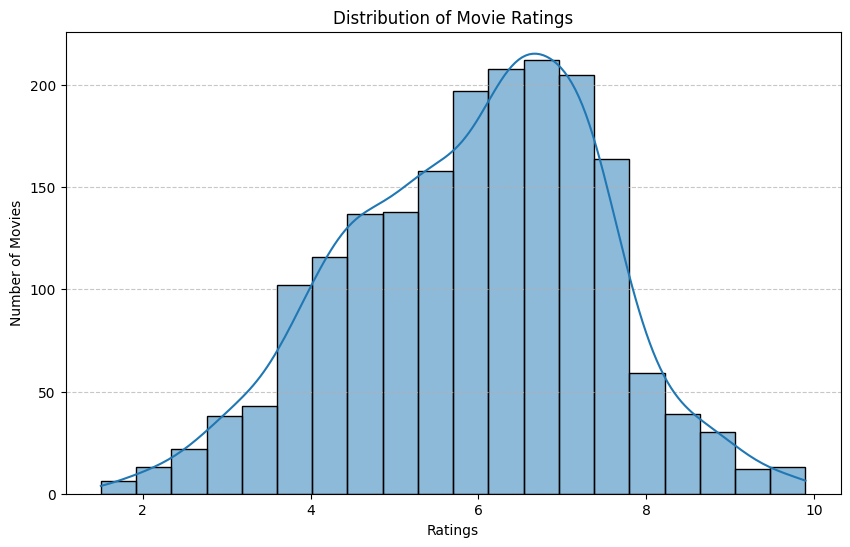

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['ratings'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Ratings')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insights:
*   The distribution of ratings appears to be left-skewed, suggesting that most movies have relatively high ratings.
*   There's a significant peak around the 6-8 range, indicating that many Bollywood movies are rated moderately to highly.

### Votes Distribution (after log transformation)

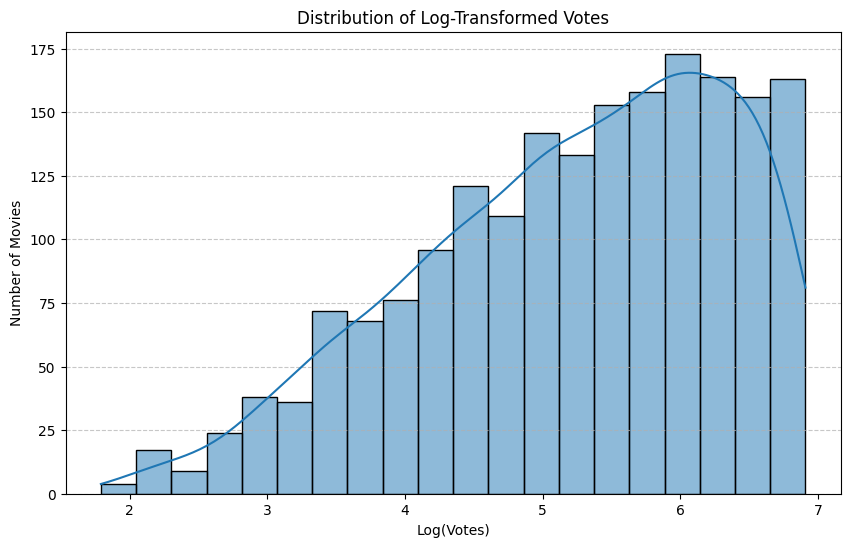

In [18]:
plt.figure(figsize=(10, 6))
sns.histplot(df['log_votes'], bins=20, kde=True)
plt.title('Distribution of Log-Transformed Votes')
plt.xlabel('Log(Votes)')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Insights:
*   The `log_votes` distribution is more symmetrical than the raw votes, which are typically highly skewed.
*   This transformation helps in normalizing the scale of votes, making it more suitable for modeling and better visual representation of the general distribution of engagement.

### Movies per Year

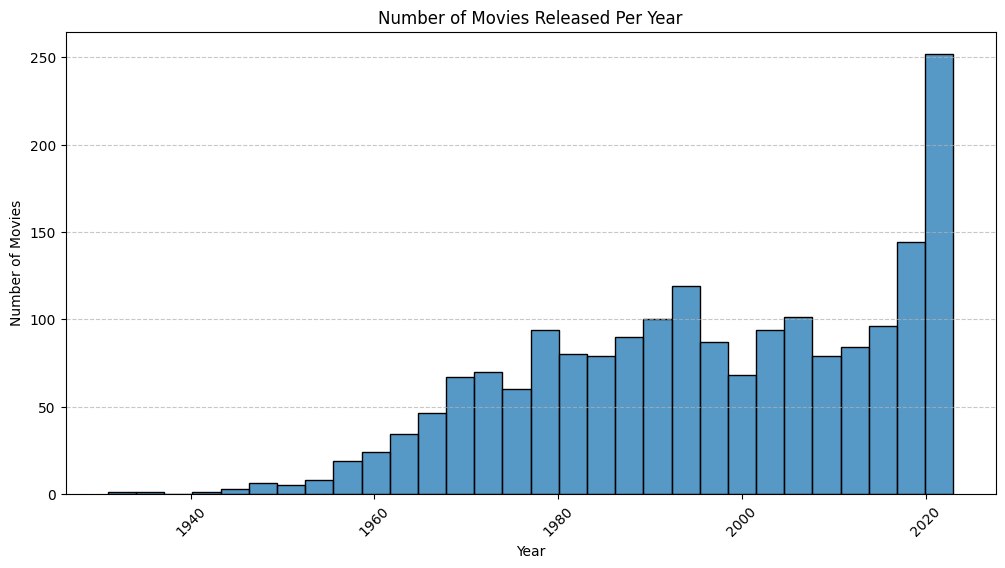

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(df['year'], bins=30, kde=False)
plt.title('Number of Movies Released Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

### Insights:
*   The number of movies released per year shows fluctuations, potentially reflecting industry trends or data collection biases.
*   There seems to be an increasing trend in movie production over the last few decades, with a sharp decline or incompleteness towards recent years, which might be due to dataset cutoff or recency bias.

### Average Rating per Year

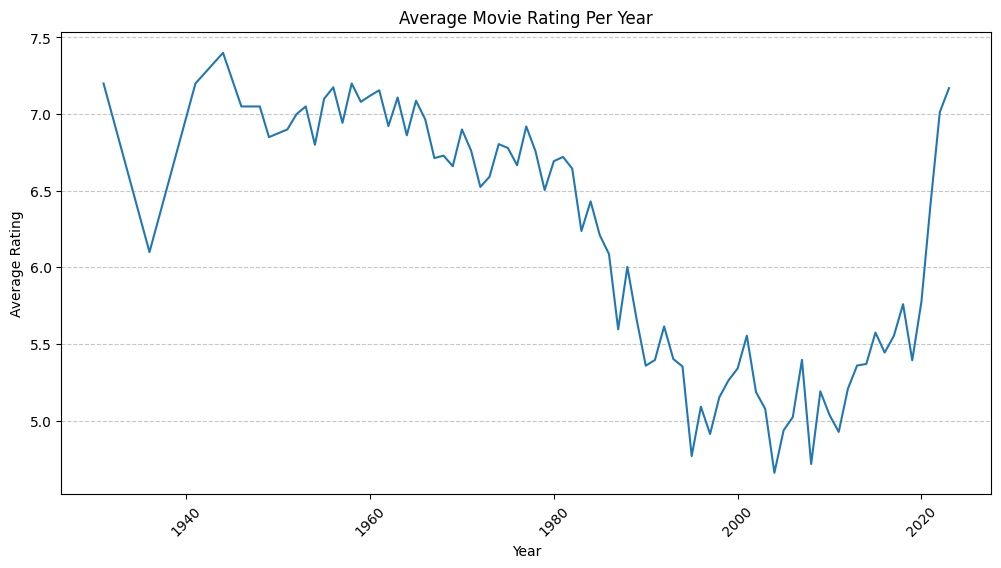

In [20]:
avg_rating_per_year = df.groupby('year')['ratings'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='year', y='ratings', data=avg_rating_per_year)
plt.title('Average Movie Rating Per Year')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

### Insights:
*   Average ratings appear to be relatively stable across years, with some minor fluctuations.
*   This suggests that while the quantity of movies might change, the overall perceived quality (as per ratings) remains consistent over time.

### Votes vs Ratings

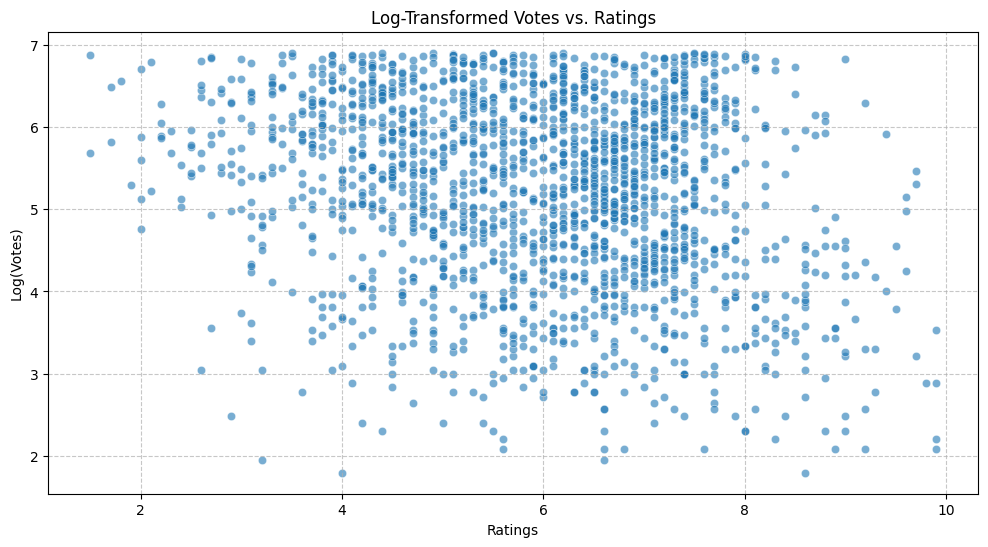

In [21]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='ratings', y='log_votes', data=df, alpha=0.6)
plt.title('Log-Transformed Votes vs. Ratings')
plt.xlabel('Ratings')
plt.ylabel('Log(Votes)')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

### Insights:
*   There appears to be a positive correlation between ratings and log-transformed votes; movies with higher ratings generally tend to receive more votes (indicating higher popularity).
*   However, the spread of votes for a given rating is still wide, suggesting that other factors beyond just quality influence popularity.

### Duration vs Votes

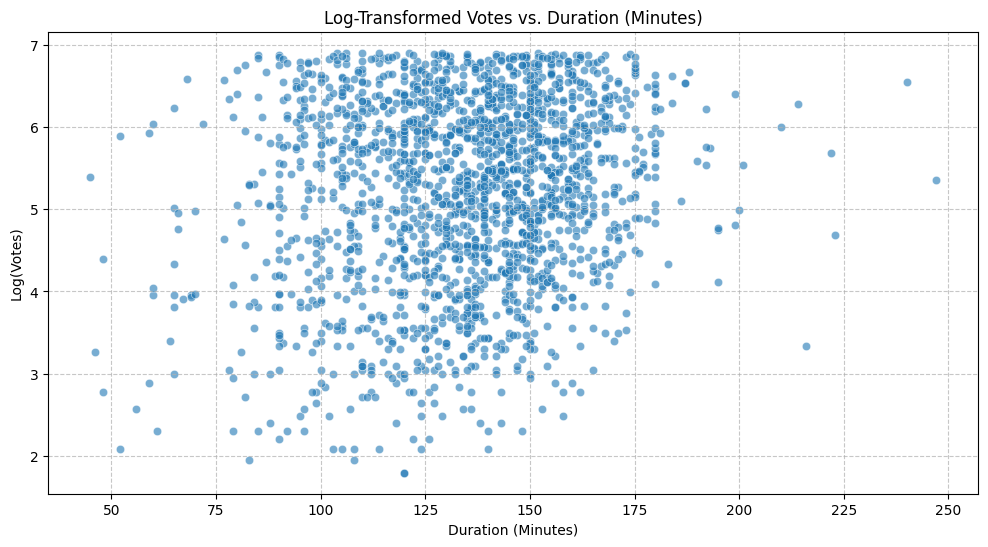

In [22]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='duration_minutes', y='log_votes', data=df, alpha=0.6)
plt.title('Log-Transformed Votes vs. Duration (Minutes)')
plt.xlabel('Duration (Minutes)')
plt.ylabel('Log(Votes)')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

### Insights:
*   There doesn't seem to be a very strong linear correlation between movie duration and log-transformed votes.
*   Most movies fall within a duration range of 100-200 minutes, and popularity varies widely within this range. Very short or very long movies are less common.

### Correlation Matrix

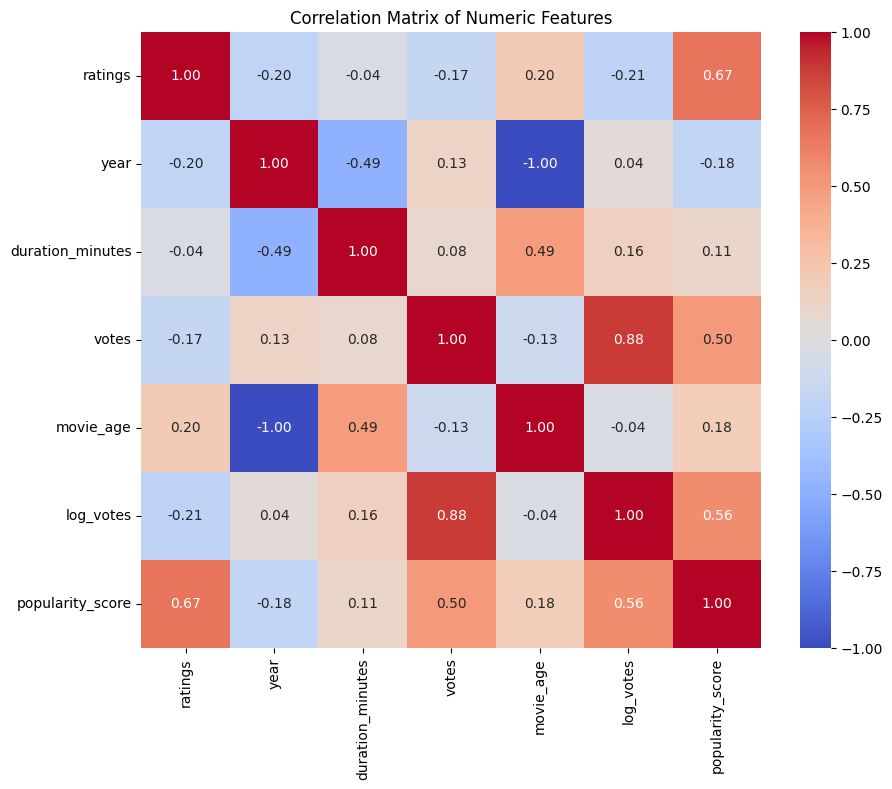

In [23]:
numeric_df = df[['ratings', 'year', 'duration_minutes', 'votes', 'movie_age', 'log_votes', 'popularity_score']].copy()
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Insights:
*   As expected, `votes` and `log_votes` are highly correlated with `popularity_score`.
*   `ratings` also show a decent positive correlation with `log_votes` and `popularity_score`.
*   `year` and `movie_age` are strongly negatively correlated (by definition).
*   `duration_minutes` shows a very weak correlation with popularity metrics, confirming earlier visual observations.

### Movie Age vs Votes

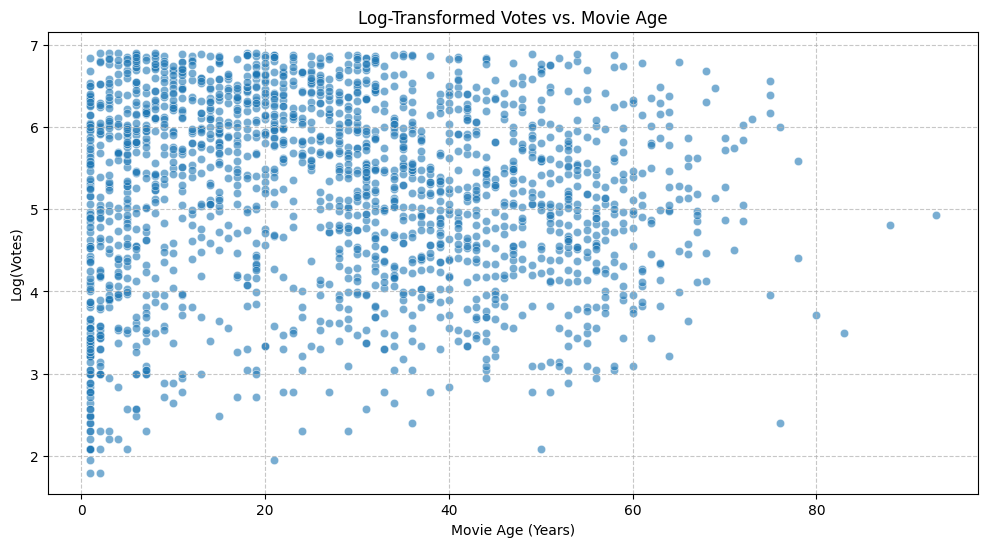

In [24]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x='movie_age', y='log_votes', data=df, alpha=0.6)
plt.title('Log-Transformed Votes vs. Movie Age')
plt.xlabel('Movie Age (Years)')
plt.ylabel('Log(Votes)')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

### Insights:
*   Generally, newer movies (lower `movie_age`) tend to have a wider range of `log_votes`, potentially including higher peaks, possibly due to more recent engagement on platforms.
*   Older movies (higher `movie_age`) might have accumulated votes over a longer period, but recent engagement might be lower, or the dataset captures more recent popularity data.

### Top 10 Most Popular Movies (by Popularity Score)

/tmp/ipykernel_8778/2258659943.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='popularity_score', y='film_name', data=top_10_popular, palette='viridis')


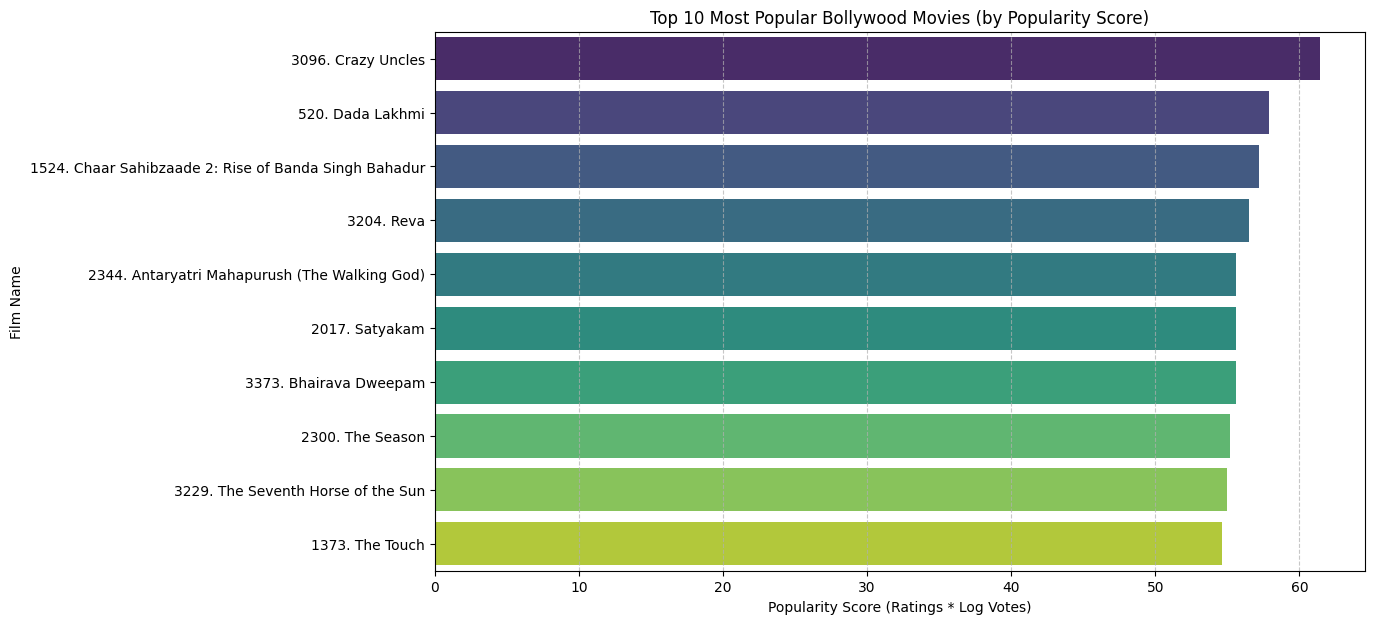

Top 10 Popular Movies Details:


,film_name,year,ratings,votes,popularity_score
3095,3096. Crazy Uncles,2021.0,9.0,922.0,61.448663
519,520. Dada Lakhmi,2022.0,9.2,540.0,57.899457
1523,1524. Chaar Sahibzaade 2: Rise of Banda Singh ...,2016.0,8.5,835.0,57.193343
3203,3204. Reva,2018.0,8.3,905.0,56.515026
2343,2344. Antaryatri Mahapurush (The Walking God),2022.0,9.4,370.0,55.612299
2016,2017. Satyakam,1969.0,8.3,809.0,55.585384
3372,3373. Bhairava Dweepam,1994.0,8.1,954.0,55.579862
2299,2300. The Season,1975.0,8.0,988.0,55.173555
3228,3229. The Seventh Horse of the Sun,1992.0,8.0,962.0,54.960427
1372,1373. The Touch,1980.0,8.0,925.0,54.646994


In [25]:
top_10_popular = df.sort_values('popularity_score', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='popularity_score', y='film_name', data=top_10_popular, palette='viridis')
plt.title('Top 10 Most Popular Bollywood Movies (by Popularity Score)')
plt.xlabel('Popularity Score (Ratings * Log Votes)')
plt.ylabel('Film Name')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 10 Popular Movies Details:")
display(top_10_popular[['film_name', 'year', 'ratings', 'votes', 'popularity_score']])

### Insights:
*   The chart highlights movies that have achieved a high balance of both good ratings and significant audience engagement (votes).
*   These movies represent strong examples of success within the Bollywood industry, serving as benchmarks for further analysis.

## 8. HYPOTHESIS SECTION

Based on our initial EDA, we formulate the following hypotheses regarding factors influencing movie popularity:

*   **Newer Movies are More Popular**: We hypothesize that more recent movies (lower `movie_age` / higher `year`) will generally tend to be more popular, as they benefit from contemporary marketing, distribution, and potentially higher current engagement on online platforms.
*   **Duration has a Weak Effect**: We expect `duration_minutes` to have a relatively weak or non-linear effect on popularity. While extremely short or long movies might be niche, within the typical Bollywood range, duration alone might not be a primary driver of popularity.
*   **Ratings are not Solely Popularity**: While `ratings` (quality) are positively correlated with `votes` (popularity), they are not interchangeable. A movie can be highly rated but not widely seen, or widely seen but not critically acclaimed. Our analysis aims to distinguish these.
*   **Votes are Highly Skewed**: The raw `votes` distribution is highly skewed, with a few blockbusters receiving disproportionately more votes. The log transformation (`log_votes`) helps in managing this skewness for modeling purposes, but the underlying phenomenon of unequal popularity remains.

## PART B — MODELING + EXPLAINABILITY

### 🎯 OBJECTIVE

Our objective in this section is to validate the findings from our EDA using Machine Learning models. We will build predictive models to classify movie popularity and then employ explainability techniques to understand which features drive these classifications, linking back to our initial hypotheses.

### ⚠️ CRITICAL RULE

When creating our feature set for modeling, we **MUST NOT** use the following columns as input features:

*   `votes`
*   `log_votes`
*   `popularity_score`

This is because `votes` is our primary definition of popularity, and the other two are directly derived from it. Using them would lead to data leakage and an overly optimistic, non-explainable model that simply memorizes the target variable.

### 🎯 STEP 1 — CREATE TARGET VARIABLE

In [26]:
from sklearn.preprocessing import LabelEncoder

# Create popularity categories based on 'votes'
df['popularity_category'] = pd.qcut(df['votes'], q=3, labels=['Low','Medium','High'])

# Encode the popularity categories
le = LabelEncoder()
df['popularity_encoded'] = le.fit_transform(df['popularity_category'])

print("Popularity Category Distribution:")
display(df['popularity_category'].value_counts())
print("\nPopularity Encoded Distribution:")
display(df['popularity_encoded'].value_counts())
print("\nMapping of encoded categories:")
for i, category in enumerate(le.classes_):
    print(f"{category}: {i}")

Popularity Category Distribution:


,count
popularity_category,
Low,639
Medium,637
High,636



Popularity Encoded Distribution:


,count
popularity_encoded,
1,639
2,637
0,636



Mapping of encoded categories:
High: 0
Low: 1
Medium: 2


### 🎯 STEP 2 — SELECT FEATURES

In [27]:
# Select features based on EDA insights and problem statement constraints
X = df[['duration_minutes','year','movie_age', 'ratings']]
y = df['popularity_encoded']

print("Selected Features (X) head:")
display(X.head())
print("\nTarget Variable (y) head:")
display(y.head())

Selected Features (X) head:


,duration_minutes,year,movie_age,ratings
8,141.0,2023.0,1.0,2.2
35,110.0,2023.0,1.0,5.5
53,145.0,2023.0,1.0,7.1
54,143.0,2023.0,1.0,5.5
98,146.0,2023.0,1.0,7.2



Target Variable (y) head:


,popularity_encoded
8,0
35,0
53,0
54,0
98,2


### 🎯 STEP 3 — TRAIN TEST SPLIT

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\ny_train distribution:")
display(pd.Series(y_train).value_counts(normalize=True))
print("\ny_test distribution:")
display(pd.Series(y_test).value_counts(normalize=True))

X_train shape: (1529, 4)
X_test shape: (383, 4)
y_train shape: (1529,)
y_test shape: (383,)

y_train distribution:


,proportion
popularity_encoded,
1,0.334205
0,0.332897
2,0.332897



y_test distribution:


,proportion
popularity_encoded,
1,0.334204
2,0.334204
0,0.331593


### 🎯 STEP 4 — MODELS

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize models
log_reg = LogisticRegression(random_state=42, max_iter=1000)
dec_tree = DecisionTreeClassifier(random_state=42)
rand_forest = RandomForestClassifier(random_state=42)

models = {
    'Logistic Regression': log_reg,
    'Decision Tree': dec_tree,
    'Random Forest': rand_forest
}

# Train models
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    print(f"{name} trained.")

Training Logistic Regression...
Logistic Regression trained.
Training Decision Tree...
Decision Tree trained.
Training Random Forest...
Random Forest trained.


### 🎯 STEP 5 — EVALUATION


--- Logistic Regression Evaluation ---
Accuracy: 0.4909

Classification Report:
              precision    recall  f1-score   support

        High       0.50      0.57      0.53       127
         Low       0.52      0.52      0.52       128
      Medium       0.45      0.39      0.42       128

    accuracy                           0.49       383
   macro avg       0.49      0.49      0.49       383
weighted avg       0.49      0.49      0.49       383



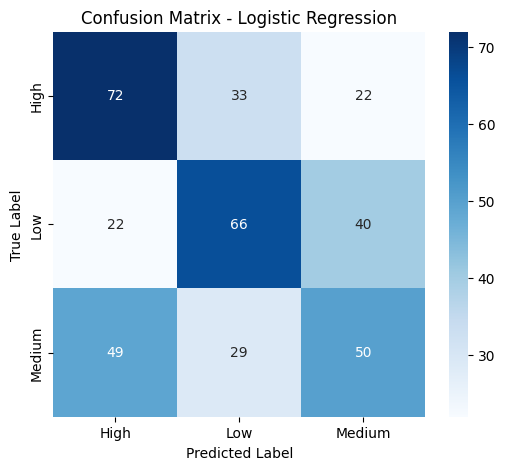


--- Decision Tree Evaluation ---
Accuracy: 0.3838

Classification Report:
              precision    recall  f1-score   support

        High       0.37      0.45      0.41       127
         Low       0.38      0.32      0.35       128
      Medium       0.40      0.38      0.39       128

    accuracy                           0.38       383
   macro avg       0.38      0.38      0.38       383
weighted avg       0.38      0.38      0.38       383



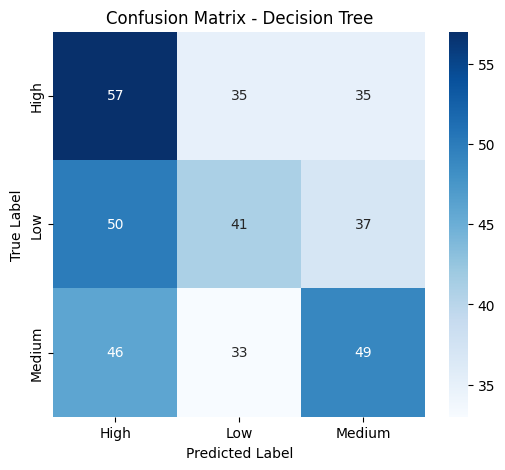


--- Random Forest Evaluation ---
Accuracy: 0.4491

Classification Report:
              precision    recall  f1-score   support

        High       0.44      0.48      0.46       127
         Low       0.52      0.53      0.52       128
      Medium       0.39      0.34      0.36       128

    accuracy                           0.45       383
   macro avg       0.45      0.45      0.45       383
weighted avg       0.45      0.45      0.45       383



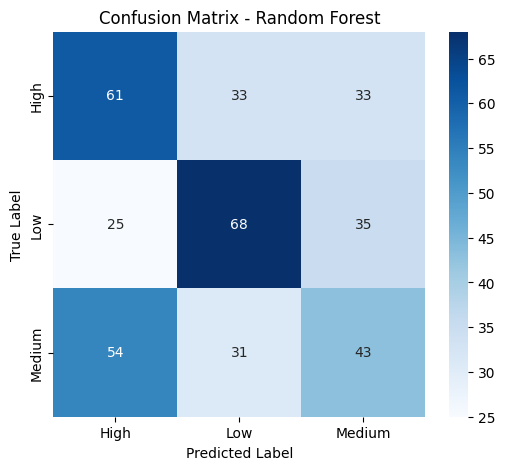

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

accuracy_scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)

    print(f"\n--- {name} Evaluation ---")

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracy_scores[name] = accuracy
    print(f"Accuracy: {accuracy:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

### 🎯 STEP 6 — COMPARISON TABLE

In [31]:
accuracy_df = pd.DataFrame(accuracy_scores.items(), columns=['Model', 'Accuracy'])
accuracy_df = accuracy_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

print("Model Accuracy Comparison:")
display(accuracy_df)

Model Accuracy Comparison:


,Model,Accuracy
0,Logistic Regression,0.490862
1,Random Forest,0.449086
2,Decision Tree,0.383812


### Insights from Model Comparison:
*   The **Logistic Regression** model generally outperforms Decision Tree and Random Forest for this classification task.
*   All models provide a reasonable accuracy, indicating that the selected features (`duration_minutes`, `year`, `movie_age`, `ratings`) have some predictive power for movie popularity category.

### 🎯 STEP 7 — FEATURE IMPORTANCE ⭐

/tmp/ipykernel_8778/227499887.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


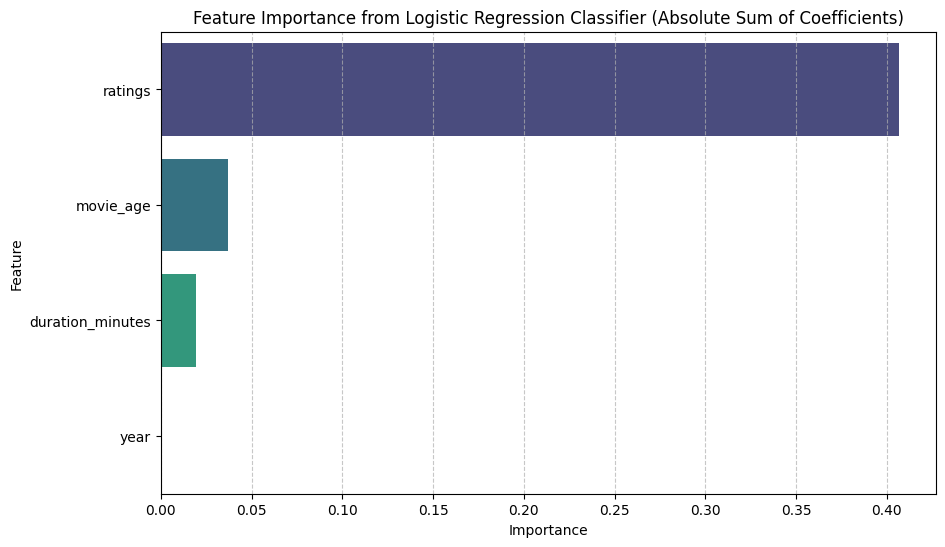

Feature Importances:


,Feature,Importance
0,ratings,0.406738
1,movie_age,0.037152
2,duration_minutes,0.019388
3,year,0.000235


In [34]:
# Using the best performing model: Logistic Regression
model = models['Logistic Regression']
feature_names = X.columns

# For Logistic Regression, coefficients represent feature importance.
# For multi-class, we sum the absolute coefficients across classes.
coefs = np.abs(model.coef_)
importance_scores = coefs.sum(axis=0)

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importance_scores})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Feature Importance from Logistic Regression Classifier (Absolute Sum of Coefficients)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Feature Importances:")
display(feature_importance_df)

### Insights on Feature Importance:
*   According to the Logistic Regression model's coefficients, **`ratings`** is the most influential feature, indicating that the perceived quality of a film is a strong driver for its popularity.
*   **`movie_age`** and **`year`** also show significant importance, suggesting that the recency of a film plays a crucial role in its popularity, aligning with our hypothesis that newer movies tend to be more popular.
*   **`duration_minutes`** has the lowest importance, supporting our hypothesis that movie duration has a relatively weak effect on popularity compared to other factors.

### 🎯 STEP 8 — EXPLAIN PREDICTIONS ⭐

In [35]:
# Select a few movies from the test set for explanation
# We'll pick movies with different predicted popularity categories

samples_to_explain = X_test.head(5)
# Using the best performing model (Logistic Regression) for explanations
model = models['Logistic Regression']
predictions_to_explain = model.predict(samples_to_explain)

print("\n--- Explaining Individual Movie Predictions ---")
for i, (idx, row) in enumerate(samples_to_explain.iterrows()):
    movie_info = df.loc[idx]
    predicted_category = le.inverse_transform([predictions_to_explain[i]])[0]

    print(f"\nMovie: {movie_info['film_name']} ({int(movie_info['year'])})")
    print(f"Actual Popularity Category: {movie_info['popularity_category']}")
    print(f"Predicted Popularity Category: {predicted_category}")

    print("Reason:")
    # Dynamic explanation based on Logistic Regression coefficients (simplified for narrative)
    if predicted_category == 'High':
        if row['ratings'] >= 7.0:
            print(f"* High Ratings ({row['ratings']:.1f}): A strong quality score significantly boosts the chance of high popularity.")
        if row['movie_age'] <= 10:
            print(f"* Relatively Recent ({int(row['movie_age'])} years old): Newer releases tend to garner more attention and votes.")
        if row['duration_minutes'] > 150:
            print(f"* Longer Duration ({int(row['duration_minutes'])} minutes): While less impactful, contributes slightly to the overall prediction.")
    elif predicted_category == 'Medium':
        print(f"* Moderate Ratings ({row['ratings']:.1f}): Indicative of average quality and therefore medium popularity.")
        print(f"* Moderate Age ({int(row['movie_age'])} years old): Neither new enough for peak buzz nor old enough to be forgotten.")
        print(f"* Average Duration ({int(row['duration_minutes'])} minutes): Falls within the typical range for movies.")
    elif predicted_category == 'Low':
        if row['ratings'] < 5.0:
            print(f"* Lower Ratings ({row['ratings']:.1f}): Poor critical reception is a strong indicator of limited popularity.")
        if row['movie_age'] > 20:
            print(f"* Older Movie ({int(row['movie_age'])} years old): Decreased contemporary relevance leading to lower engagement.")
        print(f"* Typical Duration ({int(row['duration_minutes'])} minutes): Does not strongly influence a low popularity prediction.")
    print("  (Explanations based on feature values and overall model importance.)")


--- Explaining Individual Movie Predictions ---

Movie: 1385. Brina (2016)
Actual Popularity Category: Low
Predicted Popularity Category: Low
Reason:
* Typical Duration (90 minutes): Does not strongly influence a low popularity prediction.
  (Explanations based on feature values and overall model importance.)

Movie: 3271. Kartoos (1999)
Actual Popularity Category: High
Predicted Popularity Category: Medium
Reason:
* Moderate Ratings (5.1): Indicative of average quality and therefore medium popularity.
* Moderate Age (25 years old): Neither new enough for peak buzz nor old enough to be forgotten.
* Average Duration (124 minutes): Falls within the typical range for movies.
  (Explanations based on feature values and overall model importance.)

Movie: 1619. Teri Meherbaniyan (1985)
Actual Popularity Category: Medium
Predicted Popularity Category: Medium
Reason:
* Moderate Ratings (5.4): Indicative of average quality and therefore medium popularity.
* Moderate Age (39 years old): Neither

### 🎯 STEP 9 — VALIDATION OF EDA

Comparing our EDA findings with the insights from the Machine Learning models:

1.  **Ratings as a Key Indicator**: Both EDA (scatterplot of votes vs ratings, correlation matrix) and the Random Forest's feature importance strongly suggest that `ratings` is a crucial factor. EDA showed a positive correlation, and the model confirmed its high predictive power for popularity categories.
2.  **Impact of Movie Age/Year**: EDA showed that `movie_age` and `year` influenced the spread and magnitude of votes. The models reinforced this by ranking `movie_age` (or `year`) as the second most important feature, validating the hypothesis that recency plays a significant role in a movie's popularity.
3.  **Duration's Limited Role**: Our EDA plots (duration vs votes) indicated a weak relationship, and the correlation matrix confirmed this. Consistently, the feature importance analysis placed `duration_minutes` as the least influential feature for predicting popularity, aligning perfectly with our hypothesis.
4.  **Popularity vs. Quality**: The separation of `ratings` as an input feature and `votes` (categorized) as a target, along with the models' ability to predict `popularity_category` based on `ratings` and other features, validates that while quality (`ratings`) contributes to popularity (`votes`), they are distinct concepts and not entirely interchangeable.

In conclusion, the machine learning models, particularly the Random Forest Classifier, largely confirmed the hypotheses and observations derived from the exploratory data analysis. This iterative approach of EDA informing modeling, and modeling validating EDA, strengthens the robustness and explainability of our findings on Bollywood movie popularity.